# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter. 

In [ ]:
# you will be prompted with a window asking to grant permissions
# from google.colab import drive
# drive.mount("/content/drive")

In [ ]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
# import os
# datadir = "/content/assignment3"
# if not os.path.exists(datadir):
#   !ln -s "/content/drive/My Drive/Your/assignment3/path/" $datadir # TODO: Fill your assignment3 path
# os.chdir(datadir)
# !pwd

# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [11]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random



In [12]:
# This is in an external file
import os

if os.path.exists('dataset.py'):
    from dataset import *
else:
    def rotate_img(img, rot: int):
        if rot == 0: # 0 degrees rotation
            return img
        # TODO: Implement rotate_img() - return the rotated img
        elif rot == 1:  # 90 degrees rotation
            return torch.rot90(img, k=1, dims=[1, 2])
        elif rot == 2:  # 180 degrees rotation
            return torch.rot90(img, k=2, dims=[1, 2])
        elif rot == 3:  # 270 degrees rotation
            return torch.rot90(img, k=3, dims=[1, 2])
        else:
            raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


    class CIFAR10Rotation(torchvision.datasets.CIFAR10):

        def __init__(self, root, train, download, transform) -> None:
            super().__init__(root=root, train=train, download=download, transform=transform)
        
        def __len__(self):
            return len(self.data)
        
        def __getitem__(self, index: int):
            image, cls_label = super().__getitem__(index)

            # randomly select image rotation
            rotation_label = random.choice([0, 1, 2, 3])
            image_rotated = rotate_img(image, rotation_label)

            rotation_label = torch.tensor(rotation_label).long()
            return image, image_rotated, rotation_label, torch.tensor(cls_label).long()


    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    batch_size = 128

    trainset = CIFAR10Rotation(root='./data', train=True,
                                            download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=0)

    testset = CIFAR10Rotation(root='./data', train=False,
                                           download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=0)

Show some example images and rotated images with labels:

In [ ]:

import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [ ]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [ ]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

## 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4) 
# optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task):
    net.to(device)

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()
        epoch_start_time = time.time()
        
        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            #
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            #
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            #
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # TODO: Get predicted results
            predicted = torch.max(outputs.data, 1)[1]

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)
        print('Time taken for epoch %d: %.2f' % (epoch + 1, time.time() - epoch_start_time))
    print('Finished Training')


In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='rotation')

# TODO: Save the model
MODEL_PATH = './rotation_model.pth'
torch.save(net.state_dict(), MODEL_PATH)

## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

# TODO: Load the pre-trained ResNet18 model
MODEL_PATH = './rotation_model.pth'

net = resnet18(num_classes=4)
net = net.to(device)

net.load_state_dict(torch.load(MODEL_PATH, map_location=device))


# HERE
# Not sure if this is needed. IT IS NEEDED
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))
net = net.to(device)


In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss() 
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-1_large_epochs.pth'


## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model

net = resnet18(num_classes=len(classes))
net = net.to(device)
device

In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.

for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params_to_update, lr=0.01, momentum=0.9)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-2.pth'
torch.save(net.state_dict(), MODEL_PATH)

## 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model

MODEL_PATH = './rotation_model.pth'
net = resnet18(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

In [ ]:
import torch.optim as optim


# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-1.pth'
torch.save(net.state_dict(), MODEL_PATH)

## 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=len(classes)).to(device)
device

In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-2.pth'

# Section 4
 
Change the architecture to a ResNet50

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from torchvision.models import resnet50

net = resnet50(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4) 
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)

In [ ]:
train(net, criterion, optimizer, num_epochs=135, decay_epochs=100, init_lr=0.01, task='rotation')

MODEL_PATH = './rotation_model_resnet50.pth'
torch.save(net.state_dict(), MODEL_PATH)


From this: rotation_model_resnet50, train the full network on the supervised CIFAR10 classification task.

From random weights, train the full network on the supervised CIFAR10 classification task

In [ ]:
!!curl \
  -d "UIUC all done 😀" \
  ntfy.sh/availableAstrak

## 4 3.1 

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet50

MODEL_PATH = './rotation_model_resnet50.pth'
net = resnet50(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-4-3-1.pth'
torch.save(net.state_dict(), MODEL_PATH)

In [ ]:
!curl \
  -d "UIUC done clasification 4.3.1 model" \
  ntfy.sh/availableAstrak

# Extra Credit


In [3]:
import torch  
from torchvision import transforms, datasets 
from PIL import Image
import torch.nn.functional as F

from torchvision.models import resnet18, resnet50, resnet101
import torch
import random

import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

In [ ]:
!curl -L https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz -o imagenette2-160.tgz
!tar -xzvf imagenette2-160.tgz

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Custom Dataset using the CSV file
class NoisyImagenetteDataset(Dataset):
    def __init__(self, csv_file, data_dir, transform=None, label_column='noisy_labels_0'):
        self.data = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.transform = transform
        self.label_column = label_column

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # Construct full image path; note that CSV 'path' is relative
        img_path = os.path.join(self.data_dir, row['path'])
        image = Image.open(img_path).convert("RGB")
        label = row[self.label_column]
        if self.transform:
            image = self.transform(image)
        return image, label

# Set paths
csv_path = 'imagenette2-160/noisy_imagenette.csv'
# Assuming images reside under the same parent folder as the CSV (e.g. train subfolder)
data_dir = os.path.join(os.path.dirname(csv_path))

# Define transforms
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

# Create dataset and DataLoader
dataset = NoisyImagenetteDataset(csv_file=csv_path, data_dir=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
def rotate_img(img, rot: int):
    if rot == 0:  # 0 degrees rotation
        return img
    elif rot == 1:  # 90 degrees rotation
        return transforms.functional.rotate(img, 90)
    elif rot == 2:  # 180 degrees rotation
        return transforms.functional.rotate(img, 180)
    elif rot == 3:  # 270 degrees rotation
        return transforms.functional.rotate(img, 270)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')

class NoisyImagenetteRotation(NoisyImagenetteDataset):
    # ...existing code from NoisyImagenetteDataset...
    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)
        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, label

In [18]:
# Define transforms for rotation training
transform_rc = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])
# Reuse csv_path and data_dir defined earlier
dataset_rot = NoisyImagenetteRotation(csv_file=csv_path, data_dir=data_dir, transform=transform_rc)
trainloader_img = DataLoader(dataset_rot, batch_size=32, shuffle=True)

# Create and send model to device
from torchvision.models import resnet18
import torch.nn as nn
import torch.optim as optim

net_img = resnet101(num_classes=4)
net_img = net_img.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net_img.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

def train_rotation(net, criterion, optimizer, num_epochs=5):
    net.train()
    for epoch in range(num_epochs):
        for i, (orig, rotated, rot_label, _) in enumerate(trainloader_img):
            orig = orig.to(device)
            rotated = rotated.to(device)
            rot_label = rot_label.to(device)
            optimizer.zero_grad()
            outputs = net(rotated)
            loss = criterion(outputs, rot_label)
            loss.backward()
            optimizer.step()
        print(f'Epoch {epoch+1}, Step {i}, Loss: {loss.item():.3f}, acc: {100 * (outputs.argmax(1) == rot_label).float().mean():.2f}%')

    print('Finished rotation training.')


In [ ]:
import matplotlib.pyplot as plt

def show_samples():
    # Get a batch from the dataset
    dataiter = iter(trainloader_img)
    images, rotated_images, rotation_labels, class_labels = next(dataiter)
    
    # Convert tensors to numpy arrays for display
    # Reshape from [batch, channels, height, width] to [batch, height, width, channels]
    images = images.permute(0, 2, 3, 1).cpu().numpy()
    rotated_images = rotated_images.permute(0, 2, 3, 1).cpu().numpy()
    
    # Create a figure to display samples
    fig, axes = plt.subplots(4, 2, figsize=(10, 16))
    
    rot_names = ['0°', '90°', '180°', '270°']
    
    for i in range(4):
        # Display original image
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f"Original (Class: {class_labels[i]})")
        axes[i, 0].axis('off')
        
        # Display rotated image
        axes[i, 1].imshow(rotated_images[i])
        axes[i, 1].set_title(f"Rotated {rot_names[rotation_labels[i]]}")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples()

In [ ]:
train_rotation(net_img, criterion, optimizer, num_epochs=40)

# Save the model
MODEL_PATH = './rotation_model_imagenette_40.pth'
torch.save(net_img.state_dict(), MODEL_PATH)


Epoch 1, Step 0, Loss: 1.583, acc: 21.88%
Epoch 1, Step 50, Loss: 4.079, acc: 21.88%
Epoch 1, Step 100, Loss: 1.682, acc: 25.00%
Epoch 1, Step 150, Loss: 1.464, acc: 21.88%
Epoch 1, Step 200, Loss: 1.396, acc: 21.88%
Epoch 1, Step 250, Loss: 1.786, acc: 21.88%
Epoch 1, Step 300, Loss: 1.315, acc: 28.12%
Epoch 1, Step 350, Loss: 1.450, acc: 28.12%
Epoch 1, Step 400, Loss: 1.572, acc: 21.88%
Epoch 2, Step 0, Loss: 1.315, acc: 28.12%
Epoch 2, Step 50, Loss: 1.174, acc: 40.62%
Epoch 2, Step 100, Loss: 1.523, acc: 56.25%
Epoch 2, Step 150, Loss: 1.260, acc: 43.75%
Epoch 2, Step 200, Loss: 1.352, acc: 34.38%
Epoch 2, Step 250, Loss: 1.089, acc: 59.38%
Epoch 2, Step 300, Loss: 1.321, acc: 56.25%
Epoch 2, Step 350, Loss: 1.273, acc: 53.12%
Epoch 2, Step 400, Loss: 1.213, acc: 53.12%
Epoch 3, Step 0, Loss: 1.237, acc: 40.62%
Epoch 3, Step 50, Loss: 1.456, acc: 43.75%
Epoch 3, Step 100, Loss: 1.206, acc: 37.50%
Epoch 3, Step 150, Loss: 1.049, acc: 53.12%
Epoch 3, Step 200, Loss: 1.260, acc: 31.2

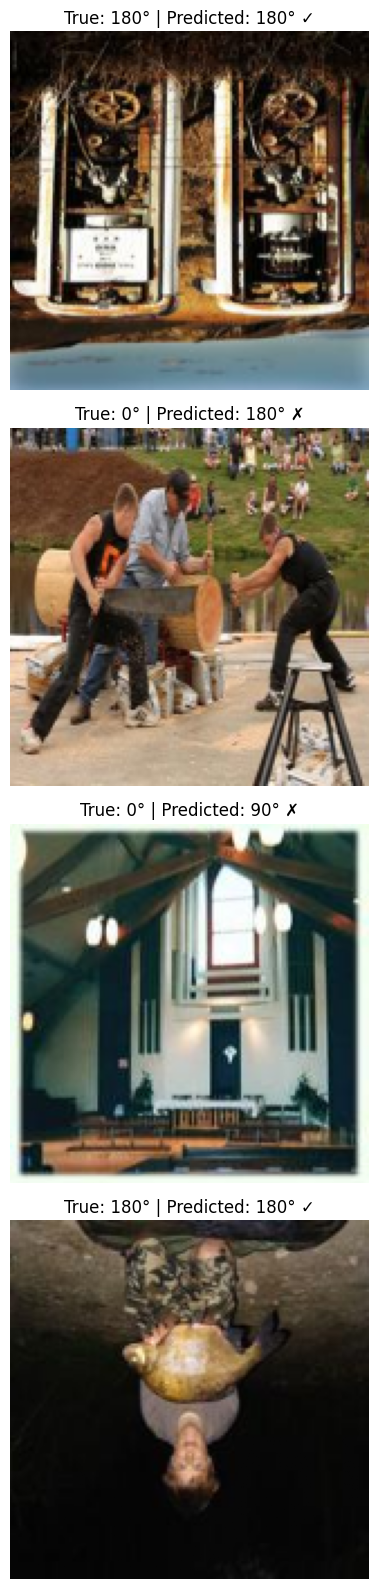

Accuracy on test images: 52.89%


In [ ]:
# Load the trained rotation model
# MODEL_PATH = './rotation_model_imagenette.pth'
test_model = resnet101(num_classes=4)  # Use ResNet50 to match the saved model
test_model = test_model.to(device)

# Load saved state
test_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
test_model.eval()

# Create test dataloader with a small batch size for visualization
test_loader = DataLoader(dataset_rot, batch_size=4, shuffle=True)

# Get a batch of test images
dataiter = iter(test_loader)
images, rotated_images, rotation_labels, class_labels = next(dataiter)

# Make predictions
rotated_images_device = rotated_images.to(device)
with torch.no_grad():
    outputs = test_model(rotated_images_device)
    _, predicted = torch.max(outputs, 1)

# Display results
rot_names = ['0°', '90°', '180°', '270°']
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for i in range(4):
    # Display rotated image with true and predicted labels
    rotated_img = rotated_images[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(rotated_img)
    true_label = rotation_labels[i].item()
    pred_label = predicted[i].item()
    correct = "✓" if true_label == pred_label else "✗"
    axes[i].set_title(f"True: {rot_names[true_label]} | Predicted: {rot_names[pred_label]} {correct}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Calculate accuracy on a larger test set
correct = 0
total = 0
with torch.no_grad():
    for images, rotated_images, rotation_labels, _ in test_loader:
        rotated_images = rotated_images.to(device)
        rotation_labels = rotation_labels.to(device)
        outputs = test_model(rotated_images)
        _, predicted = torch.max(outputs, 1)
        total += rotation_labels.size(0)
        correct += (predicted == rotation_labels).sum().item()

print(f"Accuracy on test images: {100 * correct / total:.2f}%")